# §2.3 Backtest engine

Baseline: Waelbroeck-style simulator from the fitted impact model (subtract reference-path impact, add simulated-path impact) with positions and impact states reset at the start of each day.

Expansion: engine that carries normalized impact $\bar I$ and **inventory** across days, with **overnight decay** on $\bar I$; **stock splits** handled by **excluding** tickers flagged via a daily price/volume heuristic (or a manual list).

Price path:

$$P^{\mathrm{sim}}_t = P_0 \left(1 + \mathrm{cumret}_t + \lambda\,(\bar I^{\mathrm{sim}}_t - \bar I^{\mathrm{ref}}_t)\right)$$

with $\bar I$ from the discrete OU recursion $\bar I_{t+1} = (1-\beta)\bar I_t + \tilde q_t$, $\beta = \log(2)/H_{\mathrm{bins}}$, $H_{\mathrm{bins}} = H_{\mathrm{minutes}}\times 6$ (10-second bins).

In [1]:
import sys
from pathlib import Path
import importlib

# project root = this notebook's directory
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd

import backtest_engine as be
be = importlib.reload(be)

# Sanity-check: ensure we imported the local module and it has the expected API.
print("backtest_engine loaded from:", getattr(be, "__file__", None))
missing = [
    name
    for name in (
        "multi_day_carry_from_bins",
        "multi_day_carry_paths",
        "build_daily_ohlcv_from_bins",
        "detect_splits_from_daily",
    )
    if not hasattr(be, name)
]
if missing:
    raise AttributeError(f"backtest_engine is missing expected symbols: {missing}")

backtest_engine loaded from: /Users/arthur/Documents/Quantitative Trading & Price Impact/backtest_engine.py


## Baseline: daily reset

One trading day (one `(stock, date)` segment): reference trades = tape `orderFlow`, simulated trades = your strategy. Impact states start at zero at the first bin.

In [2]:
# Example dimensions (replace with your bin-level data)
n = 1000
mid = 100.0 * np.cumprod(1.0 + 0.0001 * np.random.standard_normal(n))
q_ref = np.random.standard_normal(n) * 50
q_sim = 0.5 * q_ref + np.random.standard_normal(n) * 20

lam = 0.35
H = 60.0  # minutes, half-life
sigma = 0.02
ADV = 1e6
mt: be.ModelType = "linear"

out = be.daily_reset_backtest_path(
    mid, q_ref, q_sim, lam, H, sigma, ADV, mt
)
pnl = float(be.mark_to_market_pnl(out["p_sim"], out["position"]))
print("MTM P&L (one day, simulated mids):", pnl)
print("max |λ Ī_ref|:", np.max(np.abs(lam * out["i_ref"])))
print("max |λ Ī_sim|:", np.max(np.abs(lam * out["i_sim"])))

MTM P&L (one day, simulated mids): -206.846901795215
max |λ Ī_ref|: 6.034299756906999e-06
max |λ Ī_sim|: 4.998222111620261e-06


## Expansion: multi-day carry + splits

1. **Multi-day:** pass an ordered list of sessions `(mid, q_ref, q_sim, sigma, ADV)` for one ticker. End-of-day $\bar I$ is decayed overnight (default 16h) before the next session; **position** cumulates across sessions.

2. **Splits:** build daily `close` and `volume` from bins, run `detect_splits_from_daily`, then **exclude** those symbols from multi-day runs via `stocks_to_exclude_from_splits`.

In [3]:
sessions = []
for _ in range(3):
    m = 100.0 * np.cumprod(1.0 + 0.00005 * np.random.standard_normal(n))
    qr = np.random.standard_normal(n) * 40
    qs = 0.4 * qr
    sessions.append((m, qr, qs, sigma, ADV))

md = be.multi_day_carry_paths(
    sessions,
    lam,
    H,
    sigma,
    ADV,
    mt,
    overnight_minutes=16 * 60,
)
print("P&L per session:", md["pnl_per_session"])
print("Final carry state:", md["final_state"])

P&L per session: [-1.856101751659677, 4.2073815537586485, 52.957213545807136]
Final carry state: MultiDayState(i_bar_ref=-5.711842278391081e-11, i_bar_sim=-2.2847369113564334e-11, position=-214.06706672776443)


In [4]:
# Split detection on daily aggregates (illustrative — point bin_sample_path at your CSVs)
bin_sample_path = ROOT / "Exercise Set 1" / "binSamples" / "bin201902.csv"
if bin_sample_path.is_file():
    bins = pd.read_csv(bin_sample_path, usecols=["stock", "date", "mid", "trade"])
    daily = be.build_daily_ohlcv_from_bins(bins)
    flagged = be.detect_splits_from_daily(daily)
    bad = be.stocks_to_exclude_from_splits(flagged)
    print("Example split-flag rows:")
    print(flagged[flagged["split_flag"]].head(10).to_string())
    print("Tickers to exclude (any flag):", sorted(bad)[:20], "...")
else:
    print("Sample CSV not found; skip split demo.")

Sample CSV not found; skip split demo.


### API summary

| Function | Role |
|----------|------|
| `waelbroeck_prices(...)` | Core: `P_sim` from `mid`, `q_reference`, `q_simulated`; optional `i_bar_*0` for carry |
| `impact_state_ou` / `impact_state_project_lfilter` | OU recursion (default) vs `scipy.lfilter` match to `project.ipynb` |
| `daily_reset_backtest_path(...)` | Baseline wrapper: reset $\bar I$, one segment |
| `multi_day_carry_paths(...)` | Expansion: list of days, overnight decay, cumulative position |
| `build_daily_ohlcv_from_bins` / `detect_splits_from_daily` / `stocks_to_exclude_from_splits` | Split screening |
| `mark_to_market_pnl` | $\sum_t \mathrm{pos}_{t-1}\Delta P_t$ |

## Simple Strategy Backtest (from `binSamples` + `fillSamples`)

This notebook runs a baseline daily-reset Waelbroeck simulator using `backtest_engine.py`.

Strategy:
- Reference order flow (`q_ref`) comes from `binSamples/*` column `orderFlow`.
- Simulated trades (`q_sim`): for each ticker, if that symbol has any nonzero row in `fillSamples/*` for the month (after bucketing), use aggregated `trade` as `fill_trade`; otherwise use tape from bins (`bin_trade`) as a proxy.
- Segments `(stock, date)` are chosen from **bin** activity (nonzero tape in bins), ranked by number of days, then capped by `MAX_STOCKS` / `MAX_DAYS_PER_STOCK_PER_MONTH`.
- P&L uses the engine’s mark-to-market convention: `sum_t position_{t-1} * (P_sim[t] - P_sim[t-1])`.

You can change the months / limits in the next cell to control runtime.

In [5]:
from __future__ import annotations

import re
import sys
import importlib
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# Engine is imported in an earlier cell, but make notebook execution robust.
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import backtest_engine as be  # noqa: E402
be = importlib.reload(be)


# -------------------------
# Configuration
# -------------------------

BIN_DIR = ROOT / "binSamples"
FILL_DIR = ROOT / "fillSamples"

# Impact-model parameters (tune if you want).
lam = 0.35
half_life_min = 60.0
mt: be.ModelType = "linear"

# Strategy scaling / normalization.
# We estimate ADV per (stock, date) as sum(abs(trade)) on the bin grid.
# Then we set sigma=1.0 so q_tilde = sigma*q/ADV.
sigma = 1.0

# Runtime controls
MONTHS_TO_RUN = ["2019-01", "2019-02", "2019-03", "2019-04"]  # set to None for all overlapping months

# Multi-ticker breadth: rank symbols by activity in binSamples (# distinct dates with tape).
MAX_STOCKS = 6
MAX_DAYS_PER_STOCK_PER_MONTH = 30  # cap for runtime while keeping multiple months


def ym_from_stem(stem: str) -> str | None:
    m = re.search(r"(20\d{2})(\d{2})$", stem)
    if not m:
        return None
    return f"{m.group(1)}-{m.group(2)}"


bin_files = sorted(BIN_DIR.glob("bin20*.csv"))
fill_files = sorted(FILL_DIR.glob("fills20*.csv"))

bin_month_to_file = {ym_from_stem(p.stem): p for p in bin_files}
fill_month_to_file = {ym_from_stem(p.stem): p for p in fill_files}

available_months = sorted(set(bin_month_to_file.keys()) & set(fill_month_to_file.keys()))

if MONTHS_TO_RUN is None:
    months = available_months
else:
    months = [m for m in MONTHS_TO_RUN if m in available_months]

print("Months to run:", months)


# -------------------------
# Core bucketing + backtest
# -------------------------

segments = []
# Keep the bin-level merged data so we can run multi-day carry + split screening later.
_bins_all = []

for ym in months:
    n_seg_start = len(segments)
    bin_path = bin_month_to_file[ym]
    fill_path = fill_month_to_file[ym]

    print(f"\nProcessing month {ym}:")
    print("  bin  :", bin_path.name)
    print("  fill :", fill_path.name)

    # Load only the columns we need.
    bin_df = pd.read_csv(
        bin_path,
        usecols=["date", "time", "stock", "trade", "orderFlow", "mid"],
    ).rename(columns={"trade": "bin_trade"})

    fill_df = pd.read_csv(
        fill_path,
        usecols=["date", "time", "stock", "trade"],
    ).rename(columns={"trade": "fill_trade"})

    # Bucket both streams to the 10-second grid used by the bins.
    # binSamples times are already on the grid (no decimals), but fillSamples times have decimals.
    bin_sec = pd.to_timedelta(bin_df["time"].astype(str)).dt.total_seconds().to_numpy()
    bin_df["bin_sec"] = (np.floor(bin_sec / 10.0) * 10.0).astype(int)

    fill_sec = pd.to_timedelta(fill_df["time"].astype(str)).dt.total_seconds().to_numpy()
    fill_df["bin_sec"] = (np.floor(fill_sec / 10.0) * 10.0).astype(int)

    # Aggregate fills onto the bin grid (may cover only a subset of tickers).
    fill_agg = (
        fill_df.groupby(["stock", "date", "bin_sec"], sort=False)["fill_trade"]
        .sum()
        .reset_index()
    )

    _fill_nz = (
        fill_agg.groupby("stock", sort=False)["fill_trade"]
        .apply(lambda s: bool(np.any(np.abs(s.to_numpy(dtype=float)) > 0)))
    )
    stocks_use_fills = set(_fill_nz[_fill_nz].index.astype(str))

    # Segments from bin tape: (stock, date) with nonzero ADV proxy from bin_trade.
    has_bin = (
        bin_df.groupby(["stock", "date"], sort=False)["bin_trade"]
        .apply(lambda s: float(np.sum(np.abs(s.to_numpy(dtype=float)))) > 1e-12)
        .reset_index(name="has_activity")
    )
    has_bin = has_bin[has_bin["has_activity"]]

    if len(has_bin) == 0:
        print("  No bin segments with nonzero tape; skipping.")
        continue

    if MAX_STOCKS is not None:
        active = (
            has_bin.groupby("stock", sort=False)["date"]
            .nunique()
            .sort_values(ascending=False)
        )
        chosen_stocks = list(active.head(MAX_STOCKS).index)
        has_bin = has_bin[has_bin["stock"].isin(chosen_stocks)]
        print("  chosen stocks (from bin activity):", chosen_stocks)
        if len(chosen_stocks) < 2:
            print("  warning: fewer than 2 stocks selected from binSamples this month")
        fill_subset = sorted(stocks_use_fills & {str(s) for s in chosen_stocks})
        print("  q_sim from fillSamples for:", fill_subset if fill_subset else "(none — all use bin_trade)")

    if MAX_DAYS_PER_STOCK_PER_MONTH is not None:
        has_bin = (
            has_bin.sort_values(["stock", "date"])
            .groupby("stock", sort=False)
            .head(MAX_DAYS_PER_STOCK_PER_MONTH)
        )

    seg_keys = has_bin[["stock", "date"]]
    bin_df = bin_df.merge(seg_keys, on=["stock", "date"], how="inner")

    bins = bin_df.merge(
        fill_agg,
        on=["stock", "date", "bin_sec"],
        how="left",
    )
    bins["fill_trade"] = bins["fill_trade"].fillna(0.0)

    use_fill = bins["stock"].astype(str).isin(stocks_use_fills)
    bins["q_sim"] = bins["fill_trade"].where(use_fill, bins["bin_trade"])

    _bins_all.append(bins)

    # Backtest each (stock,date) independently (daily reset).
    grouped = bins.groupby(["stock", "date"], sort=False)

    for (stock, date), gg in grouped:
        gg = gg.sort_values("bin_sec")

        mid = gg["mid"].to_numpy(dtype=float)
        q_ref = gg["orderFlow"].to_numpy(dtype=float)
        q_sim = gg["q_sim"].to_numpy(dtype=float)
        q_bin = gg["bin_trade"].to_numpy(dtype=float)

        adv_est = float(np.sum(np.abs(q_bin)))
        if adv_est <= 1e-12:
            continue

        out = be.daily_reset_backtest_path(
            mid=mid,
            q_reference=q_ref,
            q_simulated=q_sim,
            lam=lam,
            half_life_minutes=half_life_min,
            sigma=sigma,
            adv=adv_est,
            model_type=mt,
        )

        p_sim = out["p_sim"]
        position = out["position"]

        inc_pnl = position[:-1] * np.diff(p_sim)
        pnl = float(np.sum(inc_pnl))

        gross_notional = float(np.sum(np.abs(q_sim) * mid))
        turnover_notional = float(np.sum(np.abs(q_sim) * mid))  # proxy

        segments.append(
            {
                "stock": stock,
                "date": date,
                "pnl": pnl,
                "gross_notional": gross_notional,
                "turnover_notional": turnover_notional,
                "end_position": float(position[-1]),
                "avg_abs_position": float(np.mean(np.abs(position))),
                "sum_abs_qsim": float(np.sum(np.abs(q_sim))),
            }
        )

    print("  simulated segments this month:", len(segments) - n_seg_start)

seg_df = pd.DataFrame(segments)

bins_all_df = pd.concat(_bins_all, ignore_index=True) if _bins_all else pd.DataFrame()

print("\nTotal simulated segments:", len(seg_df))
seg_df.head()

Months to run: ['2019-01', '2019-02', '2019-03', '2019-04']

Processing month 2019-01:
  bin  : bin201901.csv
  fill : fills201901.csv
  chosen stocks (from bin activity): ['A', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABC']
  q_sim from fillSamples for: ['AAPL']
  simulated segments this month: 126

Processing month 2019-02:
  bin  : bin201902.csv
  fill : fills201902.csv
  chosen stocks (from bin activity): ['A', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABC']
  q_sim from fillSamples for: ['AAPL']
  simulated segments this month: 114

Processing month 2019-03:
  bin  : bin201903.csv
  fill : fills201903.csv
  chosen stocks (from bin activity): ['A', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABC']
  q_sim from fillSamples for: ['AAPL']
  simulated segments this month: 126

Processing month 2019-04:
  bin  : bin201904.csv
  fill : fills201904.csv
  chosen stocks (from bin activity): ['A', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABC']
  q_sim from fillSamples for: ['AAPL']
  simulated segments this month: 126

Total simulated

,stock,date,pnl,gross_notional,turnover_notional,end_position,avg_abs_position,sum_abs_qsim
0,A,2019-01-02,-41.389952,1.433204e+07,1.433204e+07,-3354.0,4454.073193,217804.0
1,AAL,2019-01-02,5562.564285,2.228322e+07,2.228322e+07,-11092.0,29791.207781,691422.0
2,AAP,2019-01-02,153100.910576,2.365378e+07,2.365378e+07,-31535.0,14061.945657,149391.0
3,AAPL,2019-01-02,250261.817176,4.200709e+08,4.200709e+08,57523.0,41590.598291,2675119.0
4,ABBV,2019-01-02,-116486.490649,4.313182e+07,4.313182e+07,-125171.0,81199.045338,482047.0


## Expansion backtest: multi-day carry + split exclusion (real data)

This runs the §2.3 *expansion* on the same merged bin-level data used above:

- Carry $\bar I$ and inventory across dates within each stock (with overnight decay).
- Screen for potential splits using daily price/volume moves and **exclude** flagged tickers entirely.

In [6]:
if bins_all_df.empty:
    print("No bin-level data available (bins_all_df is empty). Run the daily-reset cell first.")
else:
    # 1) Split screening (heuristic from §2.3): large opposite price/volume moves with stable notional.
    #    `build_daily_ohlcv_from_bins` expects a column named `trade`.
    _tmp = bins_all_df.rename(columns={"bin_trade": "trade"})
    daily = be.build_daily_ohlcv_from_bins(_tmp[["stock", "date", "mid", "trade"]])
    flagged = be.detect_splits_from_daily(daily)
    exclude = be.stocks_to_exclude_from_splits(flagged)

    print(f"Split-screen: excluding {len(exclude)} tickers (any flagged day).")

    # 2) Multi-day carry backtest (per stock, across dates).
    md_df = be.multi_day_carry_from_bins(
        _tmp,
        lam=lam,
        half_life_minutes=half_life_min,
        sigma=sigma,
        model_type=mt,
        overnight_minutes=16 * 60,
        q_reference_col="orderFlow",
        q_simulated_col="q_sim",
        adv_source_col="trade",
        exclude_stocks=exclude,
    )

    print("Multi-day carry segments:", len(md_df))
    md_df.head()

Split-screen: excluding 3 tickers (any flagged day).
Multi-day carry segments: 246



Multi-day carry (expansion) summary
  days: 82
  segments: 246
  total pnl: -538042439.5002673
  sharpe (ann., daily_return): -2.8721012570175466


,Total P&L,Total Gross Notional (proxy),Win Rate,Avg Win,Avg Loss,"Sharpe (ann., daily_return)",Max Drawdown (abs P&L)
0,6.609816e+07,4.265008e+10,0.609756,1.822633e+06,-782296.992208,3.200513,-4.118982e+06


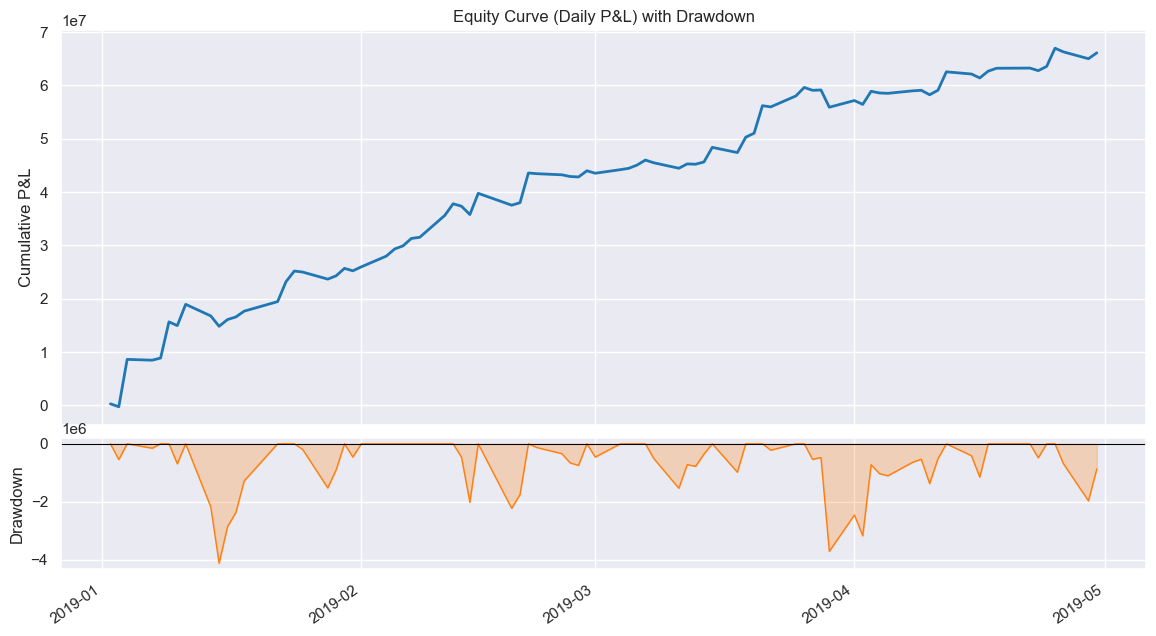

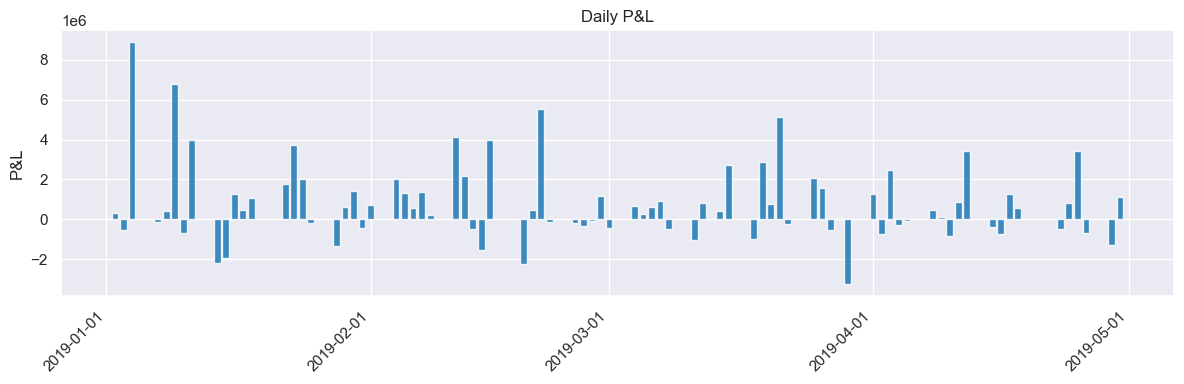

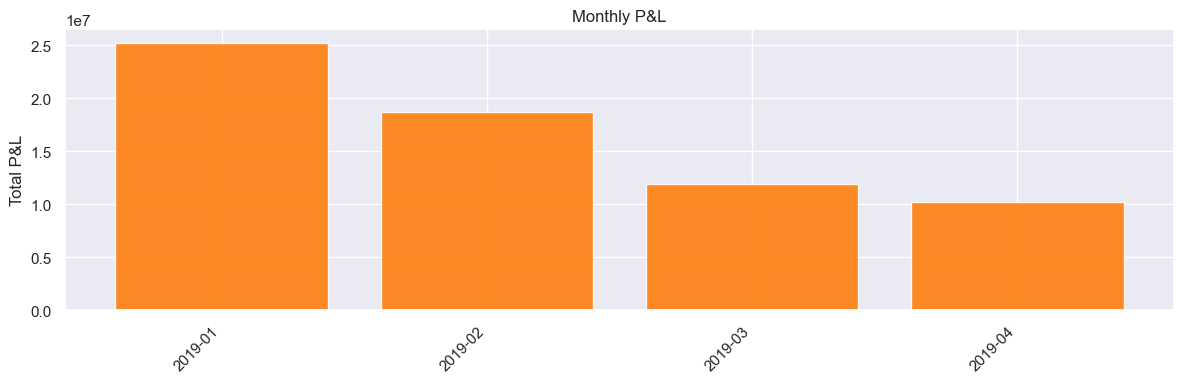

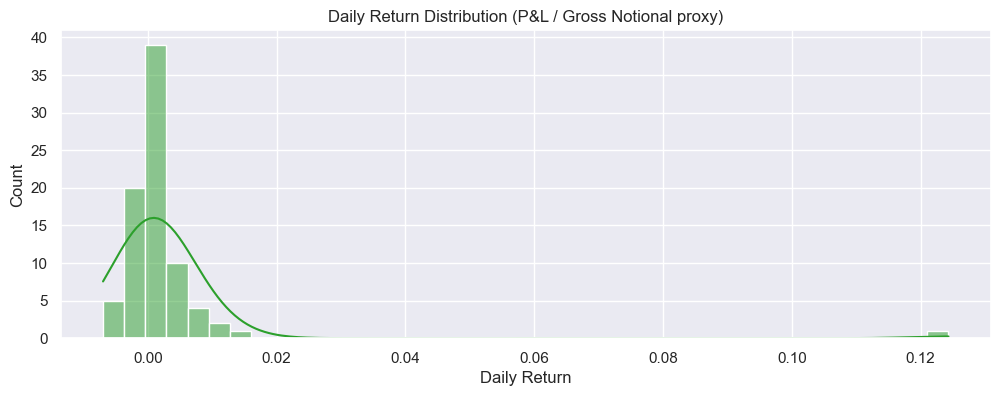

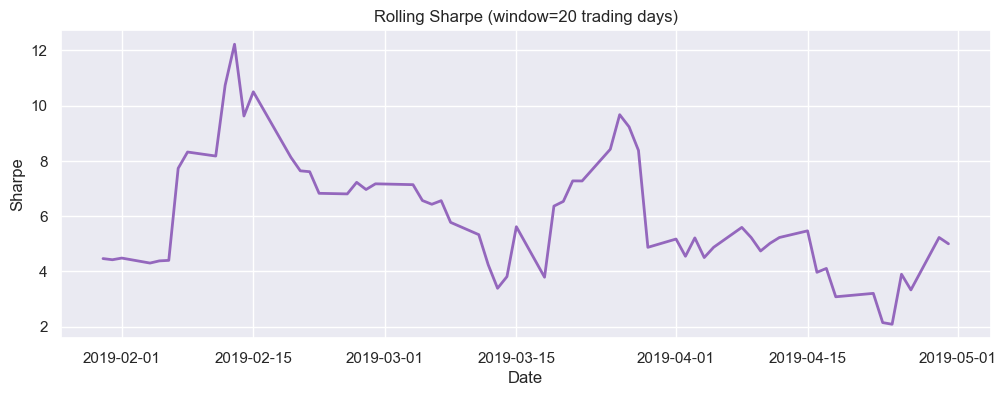

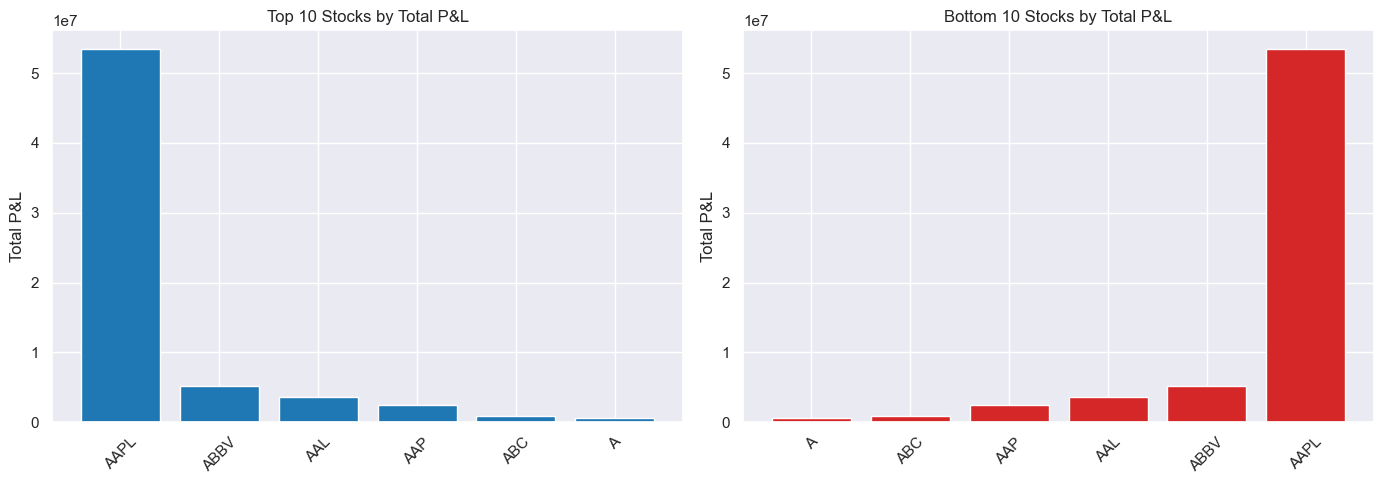

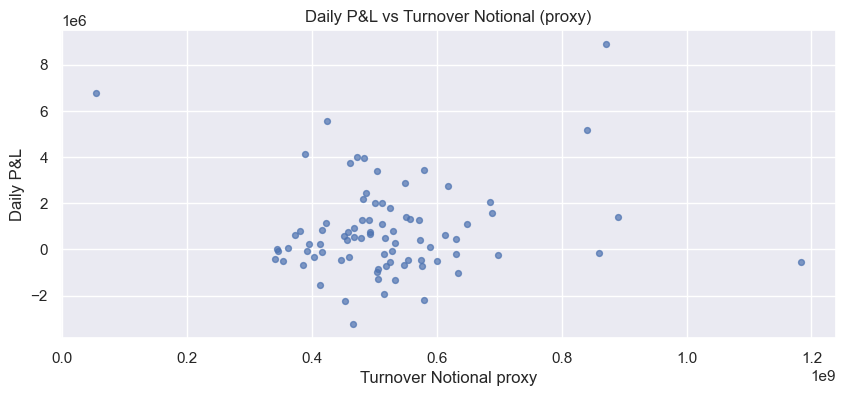

,total_pnl,mean_pnl_per_day,days_traded,gross_notional
stock,,,,
AAPL,53455974.23,651902.124716,82,3.28e+10
ABBV,5157280.54,62893.665148,82,2.76e+09
AAL,3576525.86,43616.169077,82,2.78e+09
AAP,2467019.78,30085.607056,82,1.97e+09
ABC,849321.40,10357.578060,82,1.04e+09
A,592040.67,7220.008208,82,1.28e+09


In [7]:
# -------------------------
# Performance report
# -------------------------

import matplotlib.dates as mdates
import seaborn as sns

from IPython.display import display

sns.set_theme(style="darkgrid")

# Optional: report for the multi-day carry engine (if you ran the expansion cell above).
if "md_df" in globals() and isinstance(md_df, pd.DataFrame) and not md_df.empty:
    _md = md_df.copy()
    _md["date"] = pd.to_datetime(_md["date"])
    _md_daily = (
        _md.groupby("date", sort=True)
        .agg(
            pnl=("pnl", "sum"),
            gross_notional=("gross_notional_proxy", "sum"),
            n_segments=("stock", "size"),
        )
        .sort_index()
    )
    _md_daily["daily_return"] = _md_daily["pnl"] / _md_daily["gross_notional"].replace(0, np.nan)
    _r = _md_daily["daily_return"].dropna()
    _sh = float(_r.mean() / _r.std(ddof=1) * np.sqrt(252)) if len(_r) > 1 and _r.std(ddof=1) > 0 else np.nan
    print("\nMulti-day carry (expansion) summary")
    print("  days:", len(_md_daily))
    print("  segments:", len(_md))
    print("  total pnl:", float(_md["pnl"].sum()))
    print("  sharpe (ann., daily_return):", _sh)

if seg_df.empty:
    print("No segments were simulated. Adjust MONTHS_TO_RUN / MAX_STOCKS / MAX_DAYS_PER_STOCK_PER_MONTH.")
else:
    report_df = seg_df.copy()
    report_df["date"] = pd.to_datetime(report_df["date"])

    # Daily aggregation across all stocks simulated.
    daily = (
        report_df.groupby("date", sort=True)
        .agg(
            pnl=("pnl", "sum"),
            gross_notional=("gross_notional", "sum"),
            turnover_notional=("turnover_notional", "sum"),
            n_segments=("stock", "size"),
        )
        .sort_index()
    )

    daily["daily_return"] = daily["pnl"] / daily["gross_notional"].replace(0, np.nan)

    equity = daily["pnl"].cumsum()
    peak = equity.cummax()
    drawdown = equity - peak
    max_drawdown = float(drawdown.min())
    max_drawdown_pct = float((drawdown.min() / peak.min()) * 100) if peak.min() != 0 else np.nan

    # Sharpe on daily returns (annualized).
    r = daily["daily_return"].dropna()
    sharpe = float(r.mean() / r.std(ddof=1) * np.sqrt(252)) if len(r) > 2 and r.std(ddof=1) > 0 else np.nan

    win_rate = float((daily["pnl"] > 0).mean())
    avg_win = float(daily.loc[daily["pnl"] > 0, "pnl"].mean()) if (daily["pnl"] > 0).any() else np.nan
    avg_loss = float(daily.loc[daily["pnl"] < 0, "pnl"].mean()) if (daily["pnl"] < 0).any() else np.nan

    tot_pnl = float(daily["pnl"].sum())
    tot_gross_notional = float(daily["gross_notional"].sum())

    metrics = pd.DataFrame(
        [
            {
                "Total P&L": tot_pnl,
                "Total Gross Notional (proxy)": tot_gross_notional,
                "Win Rate": win_rate,
                "Avg Win": avg_win,
                "Avg Loss": avg_loss,
                "Sharpe (ann., daily_return)": sharpe,
                "Max Drawdown (abs P&L)": max_drawdown,
            }
        ]
    )

    display(metrics)

    # -------------------------
    # Visuals
    # -------------------------

    fig = plt.figure(figsize=(14, 7))

    # Equity + drawdown panel
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)

    ax1.plot(equity.index, equity.values, color="#1f77b4", lw=2)
    ax1.set_title("Equity Curve (Daily P&L) with Drawdown")
    ax1.set_ylabel("Cumulative P&L")

    ax2.fill_between(drawdown.index, drawdown.values, 0, color="#ff7f0e", alpha=0.25)
    ax2.plot(drawdown.index, drawdown.values, color="#ff7f0e", lw=1)
    ax2.axhline(0, color="black", lw=0.8)
    ax2.set_ylabel("Drawdown")

    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=35, ha="right")

    plt.show()

    # Daily P&L bar chart (easy at-a-glance)
    plt.figure(figsize=(12, 4))
    plt.bar(daily.index, daily["pnl"].values, color="#1f77b4", alpha=0.85)
    plt.title("Daily P&L")
    plt.ylabel("P&L")
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # Monthly P&L bars
    month = daily.copy()
    month["month"] = month.index.to_period("M").astype(str)
    month_pnl = month.groupby("month")["pnl"].sum()

    plt.figure(figsize=(12, 4))
    plt.bar(month_pnl.index, month_pnl.values, color="#ff7f0e", alpha=0.9)
    plt.title("Monthly P&L")
    plt.ylabel("Total P&L")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # Return distribution
    plt.figure(figsize=(12, 4))
    sns.histplot(r, bins=40, kde=True, color="#2ca02c")
    plt.title("Daily Return Distribution (P&L / Gross Notional proxy)")
    plt.xlabel("Daily Return")
    plt.ylabel("Count")
    plt.show()

    # Rolling Sharpe
    roll_window = min(20, len(r)) if len(r) > 0 else 20
    rolling_sharpe = (
        daily["daily_return"].rolling(roll_window)
        .apply(lambda x: (x.mean() / x.std(ddof=1) * np.sqrt(252)) if x.std(ddof=1) > 0 else np.nan, raw=False)
    )

    plt.figure(figsize=(12, 4))
    plt.plot(rolling_sharpe.index, rolling_sharpe.values, color="#9467bd", lw=2)
    plt.title(f"Rolling Sharpe (window={roll_window} trading days)")
    plt.ylabel("Sharpe")
    plt.xlabel("Date")
    plt.show()

    # Top / bottom stocks by total P&L
    stock_sum = report_df.groupby("stock", sort=False).agg(
        total_pnl=("pnl", "sum"),
        mean_pnl_per_day=("pnl", "mean"),
        days_traded=("pnl", "size"),
        gross_notional=("gross_notional", "sum"),
    )

    top = stock_sum.sort_values("total_pnl", ascending=False).head(10)
    bot = stock_sum.sort_values("total_pnl").head(10)

    fig2, (ax_top, ax_bot) = plt.subplots(1, 2, figsize=(14, 5), sharex=False)

    ax_top.bar(top.index, top["total_pnl"], color="#1f77b4")
    ax_top.set_title("Top 10 Stocks by Total P&L")
    ax_top.set_ylabel("Total P&L")
    ax_top.tick_params(axis='x', rotation=45)

    ax_bot.bar(bot.index, bot["total_pnl"], color="#d62728")
    ax_bot.set_title("Bottom 10 Stocks by Total P&L")
    ax_bot.set_ylabel("Total P&L")
    ax_bot.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    # Turnover vs P&L correlation plot
    plt.figure(figsize=(10, 4))
    plt.scatter(daily["turnover_notional"], daily["pnl"], s=18, alpha=0.7)
    plt.title("Daily P&L vs Turnover Notional (proxy)")
    plt.xlabel("Turnover Notional proxy")
    plt.ylabel("Daily P&L")
    plt.show()

    # Quick tables
    display(
        stock_sum.sort_values("total_pnl", ascending=False)
        .head(15)
        .style.format({"total_pnl": "{:.2f}", "gross_notional": "{:.2e}"})
    )
